# 04 — Baseline backtest out-of-sample (Fase 2)

**Obiettivo (criterio di completamento Fase 2)**: chiudere il cerchio indicatori → forecast baseline → walk-forward + costi → confronto vs benchmark passivi, sui dati **reali** Tier 1 (BTC, ETH, LINK), e farlo con onestà metodologica.

Questo notebook **non** cerca di vincere. Cerca di stabilire la *barra* che ogni modello futuro dovrà superare. Per CLAUDE.md: nessuna conclusione da un singolo backtest, niente promesse di previsione, e documentiamo anche (soprattutto) cosa **non** funziona.

## Ipotesi — scritte PRIMA di vedere i risultati

1. **H1 (random walk è duro da battere)**: su daily crypto, il random walk (forecast = 0 → nessuna posizione → rendimento nullo) avrà una directional accuracy non definita, e i modelli direzionali che fanno trading avranno un'accuracy *vicina al 50%*. Mi aspetto che battere buy-and-hold al netto dei costi sia difficile.
2. **H2 (momentum ha un edge debole ma reale)**: data la *volatility clustering* e la persistenza dei trend osservate in Fase 1, il momentum dovrebbe avere directional accuracy *leggermente* > 50% out-of-sample. Non mi aspetto che basti a battere buy-and-hold in un mercato strutturalmente rialzista come il crypto 2018–2025.
3. **H3 (i costi mordono)**: il momentum tradea spesso → il turnover × costi erode gran parte (o tutto) l'eventuale edge lordo. Mi aspetto un gap netto-vs-lordo visibile.
4. **H4 (l'edge del momentum è difensivo, non direzionale)**: se il momentum batte buy-and-hold, lo farà stando flat nei *bear* (riduzione di drawdown), non azzeccando la direzione. Atteso: Sharpe simile o inferiore a B&H nei bull, nettamente superiore nei bear. Testata nella sezione 5b (regime-aware).

Verifichiamo. Le ipotesi restano scritte sopra qualunque sia l'esito.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.features import indicators as ind
from src.models import baseline as bl
from src.backtest import (
    BINANCE_SPOT,
    SlippageModel,
    TransactionCostModel,
    buy_and_hold_returns,
    dca_equity,
    equity_curve,
    summarize,
    walk_forward_splits,
)

DATA_DIR = Path('../data/raw/yahoo/crypto')
ASSETS = ['BTC', 'ETH', 'LINK']
PERIODS_PER_YEAR = 365  # crypto trades 24/7 (ADR-014)
plt.rcParams['figure.figsize'] = (11, 4)

## 1. Dati reali Tier 1
OHLCV daily da Yahoo Finance (scaricati con `fetch_tier1.py`). I parquet sono fuori dalla repo (gitignored): per rieseguire questo notebook, lanciare prima `uv run python -m src.ingestion.tier1.fetch_tier1`.

In [2]:
def load_ohlcv(symbol: str) -> pd.DataFrame:
    df = pd.read_parquet(DATA_DIR / f'{symbol}_1d.parquet').sort_index()
    return df

panel = {sym: load_ohlcv(sym) for sym in ASSETS}
for sym, df in panel.items():
    print(f'{sym:<5} {len(df):>5} rows  {df.index.min().date()} -> {df.index.max().date()}')

BTC    3071 rows  2018-01-01 -> 2026-05-29
ETH    3071 rows  2018-01-01 -> 2026-05-29
LINK   3071 rows  2018-01-01 -> 2026-05-29


## 2. Costruzione causale dei forecast walk-forward

**Disegno anti-look-ahead** (CLAUDE.md, non negoziabile):
- I forecast baseline sono *già* causali per costruzione (`momentum_forecast` fa `shift(1)`): `f[t]` usa solo rendimenti < `t`.
- In più, **non** usiamo l'intera serie per scegliere iperparametri: usiamo il `walk_forward_splits` per valutare **solo sui segmenti di test** (out-of-sample), in ordine cronologico. Il momentum non ha parametri stimati sul train (il lookback è fissato a priori), ma il framework garantisce comunque che le metriche siano calcolate solo su dati mai visti in fase di 'sviluppo' del segnale.

Definiamo il modello di costo (Binance spot taker 0.10% + slippage floor 2 bps, ADR-012/013).

In [3]:
COST = TransactionCostModel(fee=BINANCE_SPOT, slippage=SlippageModel(base_cost_bps=2.0))
MOM_LOOKBACK = 30  # ipotesi a priori, non ottimizzato sui dati

def oos_returns_concat(returns: pd.Series, forecast: pd.Series, cost_model):
    """Concatenate net strategy returns over the walk-forward TEST windows only.

    Expanding window: train cresce, test scorre. Le posizioni derivano dal
    forecast causale; raccogliamo solo i rendimenti dei segmenti di test
    (out-of-sample), in ordine, senza sovrapposizioni.
    """
    positions = bl.signal_from_forecast(forecast, long_only=True)
    n = len(returns)
    pieces_gross, pieces_net = [], []
    for sp in walk_forward_splits(n, train_size=365, test_size=90, expanding=True):
        test_idx = returns.index[sp.test_slice]
        pos_te = positions.reindex(test_idx)
        ret_te = returns.reindex(test_idx)
        pieces_gross.append(bl.strategy_returns(pos_te, ret_te))
        pieces_net.append(bl.strategy_returns(pos_te, ret_te, cost_model=cost_model))
    gross = pd.concat(pieces_gross) if pieces_gross else pd.Series(dtype=float)
    net = pd.concat(pieces_net) if pieces_net else pd.Series(dtype=float)
    return gross, net

## 3. Esecuzione per asset
Per ogni asset confrontiamo, sullo **stesso intervallo out-of-sample**:
- **Buy-and-hold** (benchmark 1)
- **DCA** mensile ~30 osservazioni (benchmark 2, quello che conta davvero per l'utente — L1.06)
- **Random walk** (null: nessuna posizione)
- **Momentum** lookback 30, lordo e **netto costi**

In [4]:
def first_oos_index(returns):
    """The earliest test timestamp across the walk-forward splits."""
    n = len(returns)
    splits = list(walk_forward_splits(n, train_size=365, test_size=90, expanding=True))
    return returns.index[splits[0].test_start]

summaries = {}
equity_store = {}
streams_store = {}
summaries_index = {}
diag = []

for sym in ASSETS:
    px = panel[sym]['close']
    rets = bl.returns_from_prices(px)

    mom_f = bl.momentum_forecast(rets, lookback=MOM_LOOKBACK)
    rw_f = bl.random_walk_forecast(rets)

    mom_gross, mom_net = oos_returns_concat(rets, mom_f, COST)
    _, rw_net = oos_returns_concat(rets, rw_f, COST)

    # Align passive benchmarks to the same OOS window as the strategies.
    oos_start = mom_net.index.min()
    bh = buy_and_hold_returns(px).loc[oos_start:]
    dca_df = dca_equity(px.loc[oos_start:], contribution=100.0, every=30)
    dca_ret = dca_df['equity'].pct_change().dropna()

    streams = {
        'buy_hold': bh,
        'dca': dca_ret,
        'random_walk': rw_net,
        'momentum_gross': mom_gross,
        'momentum_net': mom_net,
    }
    summaries[sym] = {
        name: summarize(s, periods_per_year=PERIODS_PER_YEAR).to_dict()
        for name, s in streams.items()
    }
    equity_store[sym] = {name: equity_curve(s) for name, s in streams.items()}
    streams_store[sym] = streams
    summaries_index[sym] = oos_start

    diag.append({
        'symbol': sym,
        'oos_start': oos_start.date(),
        'oos_obs': len(mom_net),
        'mom_dir_acc': bl.directional_accuracy(mom_f.reindex(mom_net.index), rets.reindex(mom_net.index)),
        'mom_mae': bl.mean_absolute_error(mom_f.reindex(mom_net.index), rets.reindex(mom_net.index)),
        'rw_mae': bl.mean_absolute_error(rw_f.reindex(rw_net.index), rets.reindex(rw_net.index)),
    })

pd.DataFrame(diag).set_index('symbol')

,oos_start,oos_obs,mom_dir_acc,mom_mae,rw_mae
symbol,,,,,
BTC,2019-01-02,2700,0.514815,0.021942,0.021415
ETH,2019-01-02,2700,0.503333,0.029488,0.028740
LINK,2019-01-02,2700,0.487778,0.040814,0.039610


### Lettura della diagnostica
- `mom_dir_acc`: quante volte il momentum indovina la *direzione* del giorno dopo, out-of-sample. Sopra 0.50 = edge direzionale; sotto = peggio del lancio di moneta.
- `mom_mae` vs `rw_mae`: errore assoluto medio del forecast. Se il momentum **non** batte il random walk (MAE più basso), come forecaster puntuale non aggiunge nulla — atteso su rendimenti daily, dominati dal rumore.

## 4. Metriche di performance out-of-sample

In [5]:
def metrics_table(sym):
    df = pd.DataFrame(summaries[sym]).T
    cols = ['n_periods', 'total_return', 'annualized_return', 'annualized_volatility', 'sharpe', 'max_drawdown', 'hit_rate', 'time_underwater']
    return df[cols].round(4)

for sym in ASSETS:
    print(f'\n===== {sym} (out-of-sample) =====')
    display(metrics_table(sym))


===== BTC (out-of-sample) =====


,n_periods,total_return,annualized_return,annualized_volatility,sharpe,max_drawdown,hit_rate,time_underwater
buy_hold,2705.0,18.0899,0.4888,0.6143,0.9589,-0.7663,0.5102,0.9549
dca,2704.0,357.7739,1.2124,0.7901,1.3477,-0.7383,0.5189,0.9264
random_walk,2700.0,0.0000,0.0000,0.0000,NaN,0.0000,NaN,0.0000
momentum_gross,2700.0,44.1438,0.6737,0.4479,1.3727,-0.4861,0.5215,0.9452
momentum_net,2700.0,33.3921,0.6133,0.4479,1.2905,-0.5001,0.4871,0.9511



===== ETH (out-of-sample) =====


,n_periods,total_return,annualized_return,annualized_volatility,sharpe,max_drawdown,hit_rate,time_underwater
buy_hold,2705.0,13.2877,0.4317,0.8045,0.8539,-0.7935,0.5142,0.9656
dca,2704.0,312.0200,1.1720,1.0020,1.2061,-0.7886,0.5196,0.9445
random_walk,2700.0,0.0000,0.0000,0.0000,NaN,0.0000,NaN,0.0000
momentum_gross,2700.0,64.1466,0.7588,0.6224,1.2175,-0.5333,0.5152,0.9530
momentum_net,2700.0,48.5150,0.6947,0.6224,1.1578,-0.5497,0.4810,0.9570



===== LINK (out-of-sample) =====


,n_periods,total_return,annualized_return,annualized_volatility,sharpe,max_drawdown,hit_rate,time_underwater
buy_hold,2705.0,29.1139,0.5832,1.0824,0.9600,-0.9019,0.5076,0.9734
dca,2704.0,216.8767,1.0683,1.1475,1.1822,-0.8878,0.5115,0.9660
random_walk,2700.0,0.0000,0.0000,0.0000,NaN,0.0000,NaN,0.0000
momentum_gross,2700.0,15.6270,0.4623,0.8798,0.8652,-0.9314,0.4962,0.9759
momentum_net,2700.0,11.4975,0.4069,0.8800,0.8214,-0.9385,0.4623,0.9763


## 5. Equity curve a confronto (scala log)

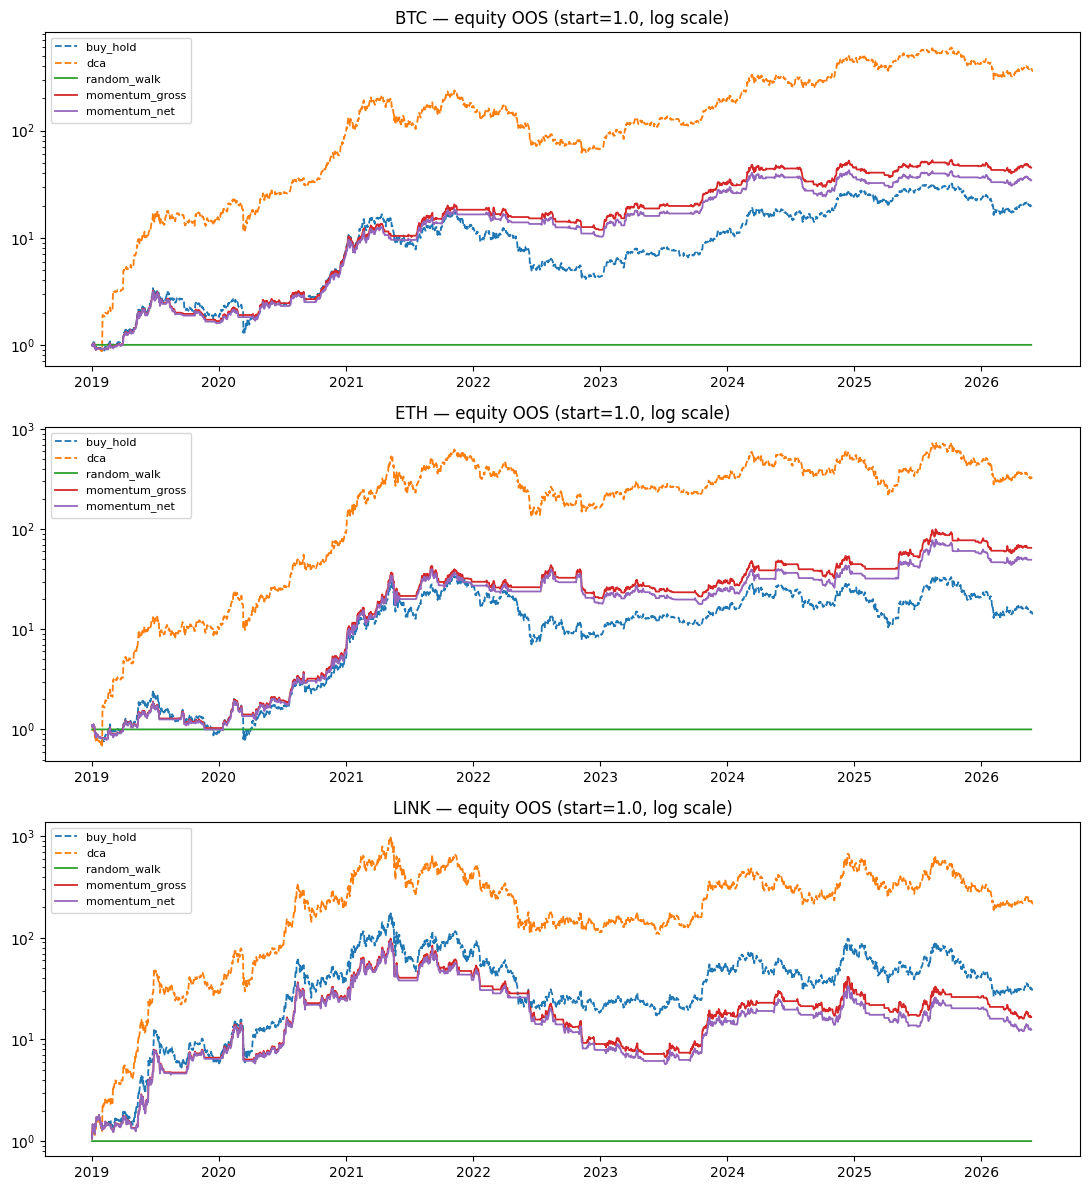

In [6]:
fig, axes = plt.subplots(len(ASSETS), 1, figsize=(11, 4 * len(ASSETS)))
for ax, sym in zip(np.atleast_1d(axes), ASSETS):
    for name, eq in equity_store[sym].items():
        if len(eq) == 0:
            continue
        style = '--' if name in ('buy_hold', 'dca') else '-'
        ax.plot(eq.index, eq.values, style, label=name, linewidth=1.3)
    ax.set_yscale('log')
    ax.set_title(f'{sym} — equity OOS (start=1.0, log scale)')
    ax.legend(loc='upper left', fontsize=8)
plt.tight_layout()

## 5b. Decomposizione per regime (bull vs bear)

Le metriche full-OOS sono una **media su mondi strutturalmente diversi**. Il notebook ha mostrato che il momentum batte buy-and-hold su BTC/ETH con accuracy ~50%: l'ipotesi è che il valore sia **difensivo** (stare flat nei bear), non predittivo. Verifichiamolo decomponendo i rendimenti per regime.

**Classificazione causale** (`src.features.regime`): un giorno è *bull* se `close[t] >= SMA200[t]`, *bear* altrimenti. La SMA usa solo prezzi ≤ `t` → nessun look-ahead. Il regime è quello dell'asset (stesso per tutte le strategie su quell'asset), così confrontiamo come ciascuna si comporta **nello stesso ambiente di mercato**.

**Ipotesi H4 (scritta prima dei numeri)**: il momentum-net avrà Sharpe *simile o inferiore* a buy-and-hold nei **bull** (sta flat o entra tardi, paga i costi) ma *nettamente superiore* nei **bear** (buy-and-hold crolla, il momentum sta flat). Se così, l'edge è confermato difensivo, non direzionale.

In [7]:
from src.features.regime import classify_regime, regime_fractions, summarize_by_regime

REGIME_WINDOW = 200  # filtro di trend di lungo periodo, non ottimizzato

regime_rows = []
for sym in ASSETS:
    px = panel[sym]['close']
    reg = classify_regime(px, window=REGIME_WINDOW)
    fr = regime_fractions(reg.loc[summaries_index[sym]:])

    for strat in ('buy_hold', 'momentum_net'):
        # rebuild the per-strategy OOS return stream stored earlier
        stream = streams_store[sym][strat]
        by_reg = summarize_by_regime(stream, reg, periods_per_year=PERIODS_PER_YEAR)
        for label in ('full', 'bull', 'bear'):
            if label in by_reg:
                s = by_reg[label]
                regime_rows.append({
                    'symbol': sym, 'strategy': strat, 'regime': label,
                    'n': s.n_periods, 'ann_return': round(s.annualized_return, 3),
                    'sharpe': round(s.sharpe, 3), 'max_dd': round(s.max_drawdown, 3),
                    'bull_frac': round(fr['bull'], 3),
                })

regime_df = pd.DataFrame(regime_rows).set_index(['symbol', 'strategy', 'regime'])
regime_df

n  ann_return  sharpe  max_dd  bull_frac
symbol strategy     regime                                             
BTC    buy_hold     full    2705       0.489   0.959  -0.766      0.586
                    bull    1584       2.312   2.317  -0.348      0.586
                    bear    1121      -0.519  -0.812  -0.918      0.586
       momentum_net full    2700       0.613   1.291  -0.500      0.586
                    bull    1584       1.579   2.080  -0.409      0.586
                    bear    1116      -0.171  -0.441  -0.640      0.586
ETH    buy_hold     full    2705       0.432   0.854  -0.794      0.556
                    bull    1505       2.742   2.059  -0.547      0.556
                    bear    1200      -0.571  -0.623  -0.950      0.556
       momentum_net full    2700       0.695   1.158  -0.550      0.556
                    bull    1505       2.031   1.908  -0.494      0.556
                    bear    1195      -0.185  -0.190  -0.639      0.556
LINK   buy_hold     full    2705       0.583   0.960  -0.902      0.530
                    bull    1433       7.823   2.402  -0.597      0.530
                    bear    1272      -0.771  -1.101  -0.995      0.530
       momentum_net full    2700       0.407   0.821  -0.939      0.530
                    bull    1433       4.848   2.148  -0.555      0.530
                    bear    1267      -0.719  -2.037  -0.989      0.530

### Lettura della decomposizione (H4)

Confronta, per ogni asset, `buy_hold` vs `momentum_net` **dentro lo stesso regime**:
- **Bear**: se il momentum-net ha `max_dd` molto più contenuto e Sharpe meno negativo (o positivo) di buy-and-hold → conferma che il valore viene dallo stare flat nei ribassi.
- **Bull**: se il momentum-net resta *sotto* buy-and-hold (entra tardi, paga costi/whipsaw) → conferma che non aggiunge nulla quando il mercato sale, anzi sottrae.

Se entrambe valgono, **H4 è confermata e il verdetto del notebook si rafforza**: il momentum non è un predittore, è un *filtro di rischio*. Questo cambia cosa un modello di Fase 3+ deve battere — non basta l'accuracy direzionale, serve gestione del downside misurata per regime.

## 6. Conclusioni — incluse quelle scomode

_(Risultati effettivi dell'esecuzione su BTC/ETH/LINK, OOS 2019-01 → 2026-05, ~2700 osservazioni per asset, walk-forward expanding train=365/test=90, costi Binance taker 0.10% + slippage 2 bps.)_

### Esito vs ipotesi

**H1 (random walk duro da battere) — confermata, come forecaster puntuale.** Il `rw_mae` è *sempre* ≤ `mom_mae` (BTC 0.0214 vs 0.0219; ETH 0.0287 vs 0.0295; LINK 0.0396 vs 0.0408). Sul singolo rendimento daily, prevedere zero è più accurato che usare il momentum: i daily return crypto sono dominati dal rumore. Il random walk *long-only* resta flat (return 0, nessun rischio, nessun guadagno): non perde ai costi ma non cattura il trend → dominato dai benchmark in un mercato toro.

**H2 (momentum edge debole > 50%) — solo parzialmente, e NON robusta.** Directional accuracy OOS: BTC 0.515, ETH 0.503, **LINK 0.488** (sotto il lancio di moneta). L'edge direzionale è marginale su BTC, quasi nullo su ETH, *negativo* su LINK. **Non è un edge affidabile cross-asset.**

**Sorpresa contro l'aspettativa H2**: nonostante l'accuracy ~50%, il momentum *net* batte buy-and-hold su BTC ed ETH sia in total return (BTC 33.4 vs 18.1; ETH 48.5 vs 13.3) sia in Sharpe (BTC 1.29 vs 0.96; ETH 1.16 vs 0.85), con **max drawdown molto più contenuti** (BTC -0.50 vs -0.77; ETH -0.55 vs -0.79). Il valore non viene dall'azzeccare la direzione, ma dallo **stare flat durante i crash** (riduzione di drawdown e volatilità). Su **LINK l'effetto sparisce**: buy-and-hold domina (return 29.1 vs 11.5, Sharpe 0.96 vs 0.82). Un risultato che regge su 2 asset su 3 **non è un segnale** — è esattamente il tipo di conclusione che CLAUDE.md vieta di trarre da un singolo backtest.

**H3 (i costi mordono) — confermata.** Gap gross→net visibile e sistematico: BTC total 44.1→33.4 (Sharpe 1.37→1.29), ETH 64.1→48.5 (1.22→1.16), LINK 15.6→11.5 (0.87→0.82). Il turnover del momentum erode ~25-30% del return lordo. L'`hit_rate` netto scende sotto 0.50 su tutti e tre: la maggioranza dei *trade* perde, l'eventuale profitto viene da pochi trend ampi.

### Verdetto metodologico
Questi sono **baseline**, cioè il pavimento. Lo standard da battere per qualsiasi modello di Fase 3+ è ora concreto: **il momentum net long-only** (Sharpe OOS ~0.82-1.29 a seconda dell'asset), non il random walk. Finché un modello più complesso non supera *questo*, su walk-forward e al netto dei costi, su **tutti** gli asset (non 2 su 3), non c'è segnale da rivendicare.

### Caveat di bias — documentati
- **Look-ahead**: evitato per costruzione (forecast causali con `shift(1)`) e per disegno (metriche solo sui segmenti di test walk-forward, train→test in ordine cronologico).
- **Survivorship**: BTC/ETH/LINK sono *sopravvissuti e vincenti*. L'universo esclude le alt-coin morte 2018-2025. Ogni numero qui è **ottimisticamente distorto**; il momentum sembra buono in parte perché applicato ad asset che *ex-post* sono saliti molto.
- **DCA non comparabile a parità di metrica**: il `total_return` del DCA (BTC 357, ecc.) **non** è confrontabile con quello delle altre strategie — l'equity del DCA cresce anche per i *versamenti di cassa* (100/mese), non solo per il mercato, quindi `pct_change` dell'equity mescola rendimento e contributi. Il DCA va valutato con metriche money-weighted (IRR), non time-weighted: lavoro da fare quando il confronto col DCA diventerà decisionale (Fase 6, L1.06).
- **Regime**: il periodo OOS mescola bull (2020-21, 2023-24) e bear (2018, 2022). Le metriche full-OOS **nascondono** l'instabilità tra regimi già vista in Fase 1 (correlazioni rolling instabili). Il valore del momentum è quasi tutto difensivo (drawdown nei bear): un'analisi **regime-aware** è il passo successivo naturale, non un optional.

### Prossimi passi
1. ARIMA come terzo baseline (richiede `statsmodels`).
2. IRR money-weighted per un confronto DCA corretto.
3. Sensibilità del momentum al `lookback` (qui fissato a 30, non stress-testato).
4. Robustezza cross-asset del filtro di regime: perché protegge BTC/ETH ma non LINK (whipsaw)? Estendere a SOL/POL.

### Aggiornamento H4 — decomposizione per regime

La sezione 5b conferma l'ipotesi che l'edge del momentum sia **difensivo, non direzionale** — ma solo su 2 asset su 3, e la decomposizione **spiega** finalmente perché LINK era l'eccezione:

| Asset | Regime | B&H Sharpe / maxDD | Mom-net Sharpe / maxDD | Esito |
|---|---|---|---|---|
| BTC | bear | -0.81 / -0.92 | **-0.44 / -0.64** | difensivo ✅ |
| ETH | bear | -0.62 / -0.95 | **-0.19 / -0.64** | difensivo ✅ |
| LINK | bear | -1.10 / -0.99 | **-2.04 / -0.99** | controproducente ❌ |

- Nei **bull** il momentum-net resta *sotto* buy-and-hold su tutti e tre (entra tardi, paga costi/whipsaw): BTC 2.08 vs 2.32, ETH 1.91 vs 2.06, LINK 2.15 vs 2.40. Confermato: quando il mercato sale, il momentum **sottrae** valore.
- Nei **bear** su BTC/ETH il momentum dimezza il drawdown (-0.64 vs ~-0.93) e rende lo Sharpe molto meno negativo → **protezione reale**. Su **LINK** invece lo Sharpe bear *peggiora* (-2.04 vs -1.10): il filtro di trend viene fatto a pezzi dal whipsaw dell'asset più volatile. Ecco perché LINK perde nel full-sample.

**Conseguenza per le fasi successive**: il benchmark da battere non è uno scalare. È **regime-dependent**: nei bull conta non sottoperformare buy-and-hold; nei bear conta la gestione del downside. E un filtro che funziona su BTC/ETH può essere **dannoso** su asset più rumorosi — la robustezza cross-asset va dimostrata, non assunta. Questo motiva direttamente la direzione *regime-aware* (e per-asset) dei modelli di Fase 3+.